In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
sus_rtlx_df = pd.read_csv("sus_rtlx_long.csv")
sus_rtlx_df.head()

,participant,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,mental,physical,temporal,performance,effort,frustration,SUS,RTLX,condition
0,1,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.000000,standard
1,2,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,2.0,0.0,40.0,10.0,0.0,0.0,0.0,97.5,8.333333,standard
2,3,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,5.0,1.0,0.0,15.0,5.0,5.0,10.0,10.0,97.5,7.500000,standard
3,4,5.0,1.0,5.0,1.0,5.0,1.0,4.0,4.0,4.0,4.0,0.0,20.0,0.0,10.0,10.0,0.0,80.0,6.666667,standard
4,5,5.0,2.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,97.5,0.000000,standard


In [23]:
# check 
odd_items  = ["S1", "S3", "S5", "S7", "S9"]
even_items = ["S2", "S4", "S6", "S8", "S10"]
rtlx_cols  = ["mental", "physical", "temporal", "performance", "effort", "frustration"]

sus_computed = (
    sus_rtlx_df[odd_items].sub(1).sum(axis=1) # computes value - 1 for each odd column for each row
    + sus_rtlx_df[even_items].rsub(5).sum(axis=1) # computes 5 - value for each even column for each row
) * 2.5

rtlx_computed = sus_rtlx_df[rtlx_cols].mean(axis=1) # mean acorss six columns (mental, physical, temporal, performance, effort, frustration)

# compares witha  small tolerance rather than exact equality 
sus_mismatch  = ~np.isclose(sus_computed, sus_rtlx_df["SUS"])
rtlx_mismatch = ~np.isclose(rtlx_computed, sus_rtlx_df["RTLX"])

print(f"SUS mismatches: {sus_mismatch.sum()}")
print(f"\nRTLX mismatches: {rtlx_mismatch.sum()}")

SUS mismatches: 0

RTLX mismatches: 0


In [24]:
sus_rtlx_df.pivot(index="participant", columns="condition", values="SUS").head()

condition,plugin,standard,voice_control
participant,,,
1,47.5,100.0,10.0
2,60.0,97.5,47.5
3,47.5,97.5,15.0
4,85.0,80.0,62.5
5,45.0,97.5,57.5


In [25]:
SCORE_CONDITIONS = ["standard", "plugin", "voice_control"]

In [26]:
# just rearranges the pivot table
sus_rtlx_df.pivot(index="participant", columns="condition", values="SUS")[SCORE_CONDITIONS].head()

condition,standard,plugin,voice_control
participant,,,
1,100.0,47.5,10.0
2,97.5,60.0,47.5
3,97.5,47.5,15.0
4,80.0,85.0,62.5
5,97.5,45.0,57.5


# Mean Results

In [27]:
sus_wide  = sus_rtlx_df.pivot(index="participant", columns="condition", values="SUS")[SCORE_CONDITIONS]
rtlx_wide = sus_rtlx_df.pivot(index="participant", columns="condition", values="RTLX")[SCORE_CONDITIONS]

print("SUS - mean (SD)")
for c in SCORE_CONDITIONS:
    print(f"  {c}: M = {sus_wide[c].mean():.2f}, SD = {sus_wide[c].std():.2f}")

print("\nRTLX - mean (SD)")
for c in SCORE_CONDITIONS:
    print(f"  {c}: M = {rtlx_wide[c].mean():.2f}, SD = {rtlx_wide[c].std():.2f}")

SUS - mean (SD)
  standard: M = 88.50, SD = 9.86
  plugin: M = 61.67, SD = 13.75
  voice_control: M = 47.83, SD = 19.66

RTLX - mean (SD)
  standard: M = 11.72, SD = 9.57
  plugin: M = 41.39, SD = 12.74
  voice_control: M = 52.28, SD = 11.08


# Boxplots

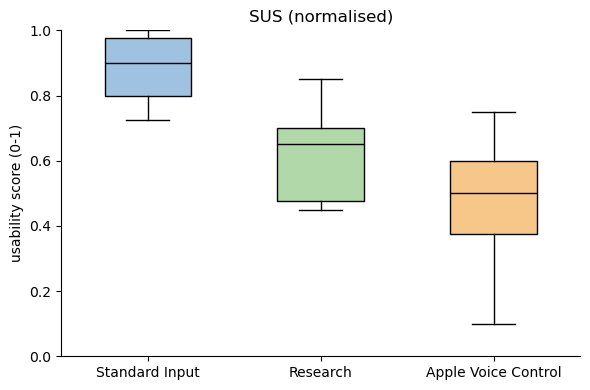

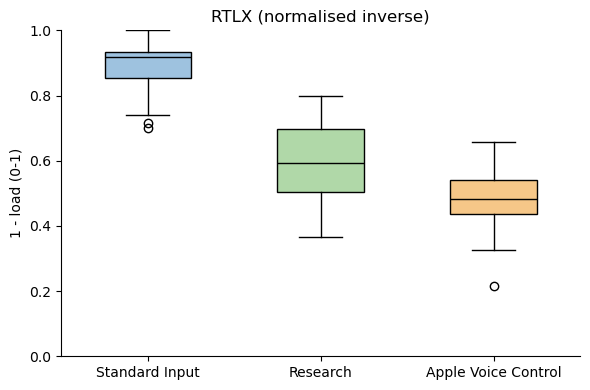

In [28]:
sus_norm  = sus_wide / 100
rtlx_norm_inv = (100 - rtlx_wide) / 100

CONDITION_COLORS = {
    "standard": "#9EC2DF",
    "voice_control": "#F6C788",
    "plugin": "#B0D8A8",
}

# Greyscale alternative
# CONDITION_COLORS = {"standard": "#f5f5f5", "voice_control": "#c7c7c7", "plugin": "#999999"}

CONDITION_DISPLAY_NAMES = {
    "standard": "Standard Input",
    "voice_control": "Apple Voice Control",
    "plugin": "Research",
}

metrics_to_plot = [
    (sus_norm,            "SUS (normalised)",          "usability score (0-1)"),
    (rtlx_norm_inv,  "RTLX (normalised inverse)", "1 - load (0-1)"),
]

def plot_condition_boxplot(wide_df, title, ylabel):
    
    values_per_condition = []
    for condition in SCORE_CONDITIONS:
        condition_values = wide_df[condition].values
        values_per_condition.append(condition_values)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    boxplot_result = ax.boxplot(values_per_condition, patch_artist=True, widths=0.5)
    
    for box_patch, condition in zip(boxplot_result["boxes"], SCORE_CONDITIONS):
        box_patch.set_facecolor(CONDITION_COLORS[condition])
        box_patch.set_alpha(1)
        
    for median_line in boxplot_result["medians"]:
        median_line.set_color("black")

    ax.set_ylim(0, 1)
    
    display_names = []
    for condition in SCORE_CONDITIONS:
        display_names.append(CONDITION_DISPLAY_NAMES[condition])
    ax.set_xticklabels(display_names)
    
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


for wide_df, title, ylabel in metrics_to_plot:
    plot_condition_boxplot(wide_df, title, ylabel)